Titanic Survival Prediction, this data is of supervised classification coz its have target column which is a categorical column, which have a binary classifier

In [ ]:
#loading basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Data loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#loading dataset
df=pd.read_csv("/content/drive/MyDrive/Jupyter/dataset/titanic.csv")

EDA


In [ ]:
#first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#last 5 rows
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
#no of rows and columns(dataset shape)
df.shape

(891, 12)

In [ ]:
#to remove unwanted column PassengerId,Name ,Ticket
df.drop(["PassengerId","Name","Ticket"],axis=1,inplace=True)

In [ ]:
#datatypes of columns
df.dtypes

,0
Survived,int64
Pclass,int64
Sex,object
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Cabin,object
Embarked,object


In [ ]:
#to check null values
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2


Preprocessing

In [ ]:
#remove Cabin column because null vaues>50%, remove Cabin column because Cabin is not imp to predict the output
df.drop("Cabin",axis=1,inplace=True)

In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [ ]:
#replace missing values in the Age column using the median because it is helps to find outliers.(numeric column)
age_median = df['Age'].median()
df['Age'].fillna(age_median, inplace=True)

In [ ]:
#verify that all nulls are handled
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,2


In [ ]:
#unique value within the 'Embarked' column, so that we can decide how to handle missing values
df["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [ ]:
#using mode here to fill missing values in the 'Embarked' column because it is a Categorical Data.
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'].fillna(embarked_mode, inplace=True)
print(f"Mode of Embarked used for imputation: {embarked_mode}")

Mode of Embarked used for imputation: S


In [ ]:
#unique values
df["Embarked"].unique()

array(['S', 'C', 'Q'], dtype=object)

In [ ]:
#rechecking null values
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
#to check unique values
df["Sex"].unique()

array(['male', 'female'], dtype=object)

In [ ]:
#to check value counts
df["Sex"].value_counts()

,count
Sex,
male,577
female,314


In [ ]:
#to check value counts
df["Survived"].value_counts()

,count
Survived,
0,549
1,342


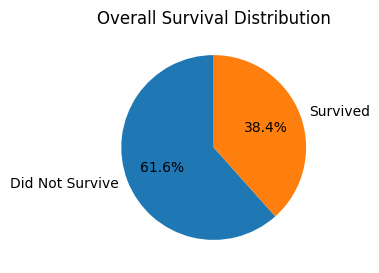

In [ ]:
#Overall Survival pie graph
survival_counts = df["Survived"].value_counts()
plt.figure(figsize=(3, 3))
plt.pie(
    survival_counts,
    labels=["Did Not Survive", "Survived"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Overall Survival Distribution")
plt.show()

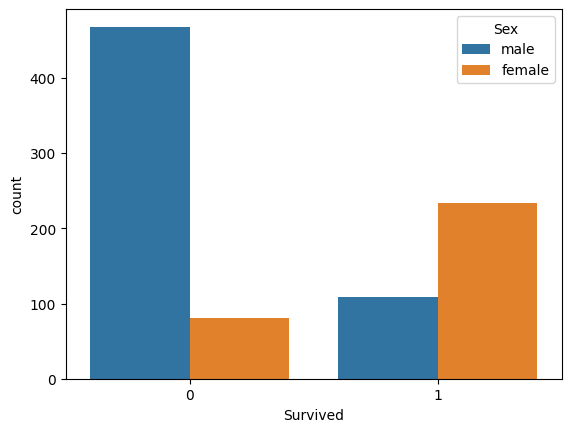

Survived  Sex   
0         female     81
          male      468
1         female    233
          male      109
Name: Sex, dtype: int64

In [ ]:
#Survival Count by Gender
sns.countplot(data=df,x="Survived",hue="Sex")
plt.show()
df.groupby(["Survived","Sex"])["Sex"].count()

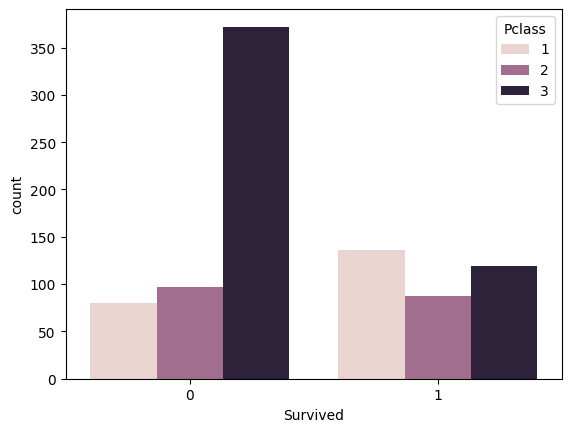

Survived  Pclass
0         1          80
          2          97
          3         372
1         1         136
          2          87
          3         119
Name: Pclass, dtype: int64

In [ ]:
#Survival Count by Passenger Class
sns.countplot(data=df,x="Survived",hue="Pclass") #output and input : Pclass
plt.show()
df.groupby(["Survived","Pclass"])["Pclass"].count()

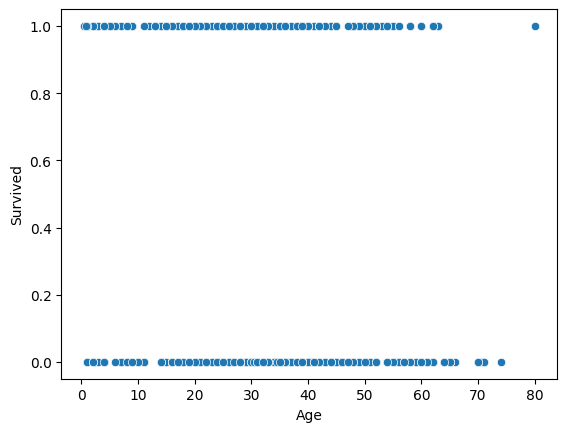

In [ ]:
#Age Distribution vs. Survival
sns.scatterplot(data=df,y="Survived",x="Age")
plt.show()

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
#label encoder
from sklearn.preprocessing import LabelEncoder

#create object of LabelEncoder
le=LabelEncoder()

# Apply label encoding to the 'Sex' column
df['Sex'] = le.fit_transform(df['Sex'])

In [ ]:
df.dtypes

,0
Survived,int64
Pclass,int64
Sex,int64
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,object


In [ ]:
#label encoder on embarked column

#create object of LabelEncoder
le=LabelEncoder()

# Apply label encoding to the 'Embarked' column
df['Embarked'] = le.fit_transform(df['Embarked'])

In [ ]:
df.dtypes

,0
Survived,int64
Pclass,int64
Sex,int64
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,int64


In [ ]:
#Define Features & Target
x = df.drop('Survived', axis=1)
y = df['Survived']

In [ ]:
#Train-Test Split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

In [ ]:
x_train.shape,x_test.shape

((623, 7), (268, 7))

In [ ]:
y_train.shape,y_test.shape

((623,), (268,))

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
ss=StandardScaler()
x_train=ss.fit_transform(x_train)
x_test=ss.transform(x_test)

In [ ]:
#create a user defined function
def create_model(model):
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    print(confusion_matrix(y_test,y_pred))
    print(classification_report(y_test,y_pred))
    return model

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

In [ ]:
#Perform the model with logistic Regression class
from sklearn.linear_model import LogisticRegression

In [ ]:
#create the object of LogisticRegression class
lr=LogisticRegression()

In [ ]:
#call function and passing the object of LogisticRegression class
lr=create_model(lr)

[[130  23]
 [ 37  78]]
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       153
           1       0.77      0.68      0.72       115

    accuracy                           0.78       268
   macro avg       0.78      0.76      0.77       268
weighted avg       0.78      0.78      0.77       268



accuracy=78
recall=68

In [ ]:
#Now use next algorithm of classification : DecisionTreeClassifier
#call DecisionTreeClassifier   with gini index
from sklearn.tree import DecisionTreeClassifier

In [ ]:
#create the object of DecisionTreeClassifier  class
dt= DecisionTreeClassifier(random_state=1) #bydefault criterion="gini"

In [ ]:
dt=create_model(dt)

[[129  24]
 [ 41  74]]
              precision    recall  f1-score   support

           0       0.76      0.84      0.80       153
           1       0.76      0.64      0.69       115

    accuracy                           0.76       268
   macro avg       0.76      0.74      0.75       268
weighted avg       0.76      0.76      0.75       268



accuracy=76
recall=64

In [ ]:
#check information gain of each inputs
dt.feature_importances_

array([0.11431867, 0.33027867, 0.25060369, 0.06312897, 0.00135823,
       0.21187956, 0.02843221])

In [ ]:
dict={'Input Column':x.columns,'Information gain':dt.feature_importances_}
#converts into  dataframe
df1=pd.DataFrame(dict)
df1.sort_values("Information gain",ascending=False,ignore_index=True)

,Input Column,Information gain
0,Sex,0.330279
1,Age,0.250604
2,Fare,0.211880
3,Pclass,0.114319
4,SibSp,0.063129
5,Embarked,0.028432
6,Parch,0.001358


In [ ]:
#perform model with DecisionTreeClassifier using entropy
#create the object of DecisionTreeClassifier  class
dt=DecisionTreeClassifier(random_state=1,criterion="entropy") #bydefault criterion="gini

In [ ]:
#call function and passing the object of DecisionTreeClassifier using entropy
dt=create_model(dt)

[[127  26]
 [ 42  73]]
              precision    recall  f1-score   support

           0       0.75      0.83      0.79       153
           1       0.74      0.63      0.68       115

    accuracy                           0.75       268
   macro avg       0.74      0.73      0.74       268
weighted avg       0.75      0.75      0.74       268



accuracy=75
recall=63

In [ ]:
dict={'Input Column':x.columns,'Information gain':dt.feature_importances_}
#converts into  dataframe
df1=pd.DataFrame(dict)
df1.sort_values("Information gain",ascending=False,ignore_index=True)

,Input Column,Information gain
0,Age,0.271028
1,Sex,0.256494
2,Fare,0.252514
3,Pclass,0.115775
4,SibSp,0.054580
5,Embarked,0.027995
6,Parch,0.021615


In [ ]:
#decision tree with gini index : GINIINDEX
dt=DecisionTreeClassifier(random_state=1,max_depth=6)
dt=create_model(dt)

[[140  13]
 [ 44  71]]
              precision    recall  f1-score   support

           0       0.76      0.92      0.83       153
           1       0.85      0.62      0.71       115

    accuracy                           0.79       268
   macro avg       0.80      0.77      0.77       268
weighted avg       0.80      0.79      0.78       268



accuracy = 79
recall =62

In [ ]:
dict={'Input Column':x.columns,'Information gain':dt.feature_importances_}
#converts into  dataframe
df1=pd.DataFrame(dict)
df1.sort_values("Information gain",ascending=False,ignore_index=True)

,Input Column,Information gain
0,Sex,1.0
1,Pclass,0.0
2,Age,0.0
3,SibSp,0.0
4,Parch,0.0
5,Fare,0.0
6,Embarked,0.0


In [ ]:
#decision tree with gini index : use max_depth
dt=DecisionTreeClassifier(random_state=1,max_depth=7,criterion="entropy")
dt=create_model(dt)

[[142  11]
 [ 45  70]]
              precision    recall  f1-score   support

           0       0.76      0.93      0.84       153
           1       0.86      0.61      0.71       115

    accuracy                           0.79       268
   macro avg       0.81      0.77      0.77       268
weighted avg       0.80      0.79      0.78       268



accuracy=79
recall=61

In [ ]:
#2nd pruning technique - min_samples_leaf to reduce overfitting of model, leaf has no child

In [ ]:
#DecisionTree with GINIINDEX & min_samples_leaf
dt=DecisionTreeClassifier(random_state=1,min_samples_leaf=45)
dt=create_model(dt)

[[142  11]
 [ 50  65]]
              precision    recall  f1-score   support

           0       0.74      0.93      0.82       153
           1       0.86      0.57      0.68       115

    accuracy                           0.77       268
   macro avg       0.80      0.75      0.75       268
weighted avg       0.79      0.77      0.76       268



accuracy=77
recall =57

In [ ]:
dict={'Input Column':x.columns,'Information gain':dt.feature_importances_}
#converts into  dataframe
df1=pd.DataFrame(dict)
df1.sort_values("Information gain",ascending=False,ignore_index=True)

,Input Column,Information gain
0,Sex,0.710705
1,Pclass,0.174084
2,Fare,0.066642
3,Age,0.048569
4,SibSp,0.000000
5,Parch,0.000000
6,Embarked,0.000000


In [ ]:
#DecisionTree with entropy & min_samples_leaf
dt=DecisionTreeClassifier(random_state=1,min_samples_leaf=7,criterion="entropy")
dt=create_model(dt)

[[132  21]
 [ 39  76]]
              precision    recall  f1-score   support

           0       0.77      0.86      0.81       153
           1       0.78      0.66      0.72       115

    accuracy                           0.78       268
   macro avg       0.78      0.76      0.77       268
weighted avg       0.78      0.78      0.77       268



accuracy =78
recall=66

In [ ]:
#Ensembling technique
#RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#decision tree min 10 and max 100
rfc=RandomForestClassifier(random_state=1,n_estimators=20)
rfc=create_model(rfc)

[[139  14]
 [ 39  76]]
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       153
           1       0.84      0.66      0.74       115

    accuracy                           0.80       268
   macro avg       0.81      0.78      0.79       268
weighted avg       0.81      0.80      0.80       268



accuracy=80
recall=66

In [ ]:
#show information gain of each inputs
rfc.feature_importances_

array([0.08420163, 0.2436498 , 0.2677772 , 0.05821256, 0.04614367,
       0.26705957, 0.03295557])

In [ ]:
x.columns

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'], dtype='object')

In [ ]:
dict={'Input Column':x.columns,'Information gain':rfc.feature_importances_}
#converts into  dataframe
df1=pd.DataFrame(dict)
df1.sort_values("Information gain",ascending=False,ignore_index=True)

,Input Column,Information gain
0,Age,0.267777
1,Fare,0.267060
2,Sex,0.243650
3,Pclass,0.084202
4,SibSp,0.058213
5,Parch,0.046144
6,Embarked,0.032956


In [ ]:
#RFC works on bagging
#Next ensembling technique: boosting technique
#extreme gradient boost (XGB) : works on decision tree
#requires package known as xgboost
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb=XGBClassifier(n_estimators=11,random_state=1,reg_alpha=1)
#create object of RandomForestClassifier class and pass the following, n_estimators = no.of decision tree to trsin model
print("No.of Decision Tree: 30")
#call function and send the object of RFC class
xgb=create_model(xgb)

No.of Decision Tree: 30
[[138  15]
 [ 46  69]]
              precision    recall  f1-score   support

           0       0.75      0.90      0.82       153
           1       0.82      0.60      0.69       115

    accuracy                           0.77       268
   macro avg       0.79      0.75      0.76       268
weighted avg       0.78      0.77      0.77       268



accuracy = 77,78
recall = 60,59

In [ ]:
dict={'Input Column':x.columns,'Information gain':xgb.feature_importances_}
#converts into  dataframe
df1=pd.DataFrame(dict)
df1.sort_values("Information gain",ascending=False,ignore_index=True)

,Input Column,Information gain
0,Sex,0.751000
1,Pclass,0.128971
2,Embarked,0.040276
3,SibSp,0.034882
4,Age,0.023372
5,Fare,0.013823
6,Parch,0.007676


In [ ]:
'''
Algorithm Name                                               	Accuracy	Recall Score
1. Logistic Regression                                           78       68
2. DecisionTree with GINI                                        76       64
3. DecisionTree with Entropy                                     75      	63
4. Pruning Tech.
   A. DecisionTree with GINIINDEX & max_depth=6                  79 	    62
   B. DecisionTree with Entropy & max_depth=7             	     79   	  61
   C. DecisionTree with GINIINDEX & min_samples_leaf=45      	   77       57
   D. DecisionTree with entropy & min_samples_leaf=7             79       61
5. Ensembling Technique
  A.RandomForestClassifier                                       80       66 ---> BEST FIT
  B.XGBoost                                                      77       60
'''


 MODEL COMPARISON
              Model  Accuracy
      Random Forest      0.80
Logistic Regression      0.78
      Decision Tree      0.76


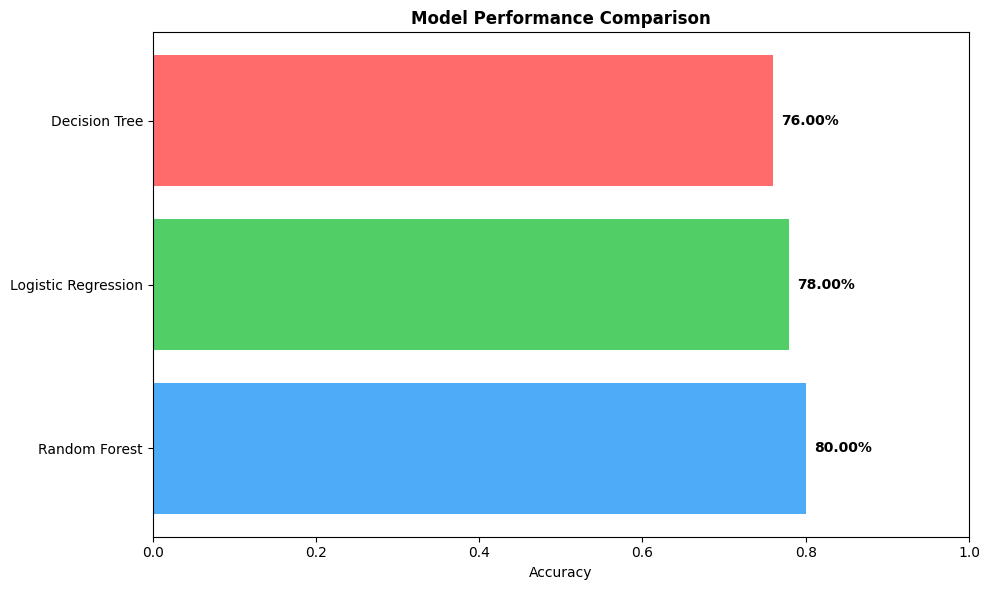

In [ ]:
#  Compare Models
print("\n MODEL COMPARISON")

# Manually define accuracy scores based on previous model executions
# Accuracy for Logistic Regression (from cell DINi_yH5Quuj)
acc_lr = 0.78
# Accuracy for Decision Tree (from cell Lex58y2AQ-cb, default gini)
acc_dt = 0.76
# Accuracy for Random Forest (from cell DajfSpClUo8r)
acc_rf = 0.80

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [acc_lr, acc_dt, acc_rf]
}).sort_values('Accuracy', ascending=False)

print(results.to_string(index=False))

# Visualization
plt.figure(figsize=(10, 6))
bars = plt.barh(results['Model'], results['Accuracy'],
                color=['#4dabf7', '#51cf66', '#ff6b6b'])
plt.xlabel('Accuracy')
plt.title('Model Performance Comparison', fontweight='bold')
plt.xlim(0, 1)

for bar, acc in zip(bars, results['Accuracy']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{acc:.2%}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Make Final Predictions
print("MAKING FINAL PREDICTIONS")

#Train final model on all training data
final_model = RandomForestClassifier(random_state=1, n_estimators=20, max_depth=7)
final_model.fit(x_train, y_train)

# Predict on test data
test_predictions = final_model.predict(x_test)

print(f" Predictions complete")
print(f"   Predicted to survive: {sum(test_predictions == 1)}")
print(f"   Predicted not to survive: {sum(test_predictions == 0)}")

MAKING FINAL PREDICTIONS
 Predictions complete
   Predicted to survive: 87
   Predicted not to survive: 181


In [ ]:
#  Feature Importance
print("\n FEATURE IMPORTANCE")


feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Most important features for survival:")
for i, row in feature_importance.iterrows():
    print(f"  {i+1:2}. {row['Feature']:15} - {row['Importance']:.3f}")


 FEATURE IMPORTANCE
Most important features for survival:
   2. Sex             - 0.359
   6. Fare            - 0.210
   3. Age             - 0.162
   1. Pclass          - 0.122
   4. SibSp           - 0.061
   5. Parch           - 0.047
   7. Embarked        - 0.040
